In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt

# 👉 Point this to file in Colab
CSV_PATH = "/content/Order_Data_meriskill.csv"

df = pd.read_csv(CSV_PATH, low_memory=False)

# Dates
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")
df = df.dropna(subset=["OrderDate"]).copy()

# IDs as tidy strings
for col in ["CustID", "OrderID"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# numeric cleaning
def to_num(x):
    if pd.isna(x): return np.nan
    s = str(x).replace("£","").replace("$","").replace(",","").strip()
    s = pd.Series([s]).str.replace(r"[^0-9\.\-]", "", regex=True).iloc[0]
    if s in ("", ".", "-"): return np.nan
    try: return float(s)
    except: return np.nan

for col in ["ProductPrice", "ProductCost", "OrderQuantity"]:
    if col in df.columns:
        df[col] = df[col].apply(to_num)


#Financial Performance Analysis
# Compute profit and ROI
df["Revenue"] = df["ProductPrice"] * df["OrderQuantity"]
df["Cost"] = df["ProductCost"] * df["OrderQuantity"]
df["Profit"] = df["Revenue"] - df["Cost"]
df["ROI"] = (df["Profit"] / df["Cost"]) * 100

# Group by campaign or product
financial_summary = (
    df.groupby("AcquisitionSource")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Cost=("Cost", "sum"),
          Total_Profit=("Profit", "sum"),
          Avg_ROI=("ROI", "mean")
      )
      .reset_index()
)

financial_summary

,AcquisitionSource,Total_Revenue,Total_Cost,Total_Profit,Avg_ROI
0,Google-ads\r,7.803858e+06,4.527809e+06,3.276049e+06,131.939472
1,Meta-ads\r,9.712501e+05,5.628851e+05,4.083650e+05,133.142301
2,Yt-Campaign\r,1.047955e+06,6.078927e+05,4.400624e+05,131.050505


) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


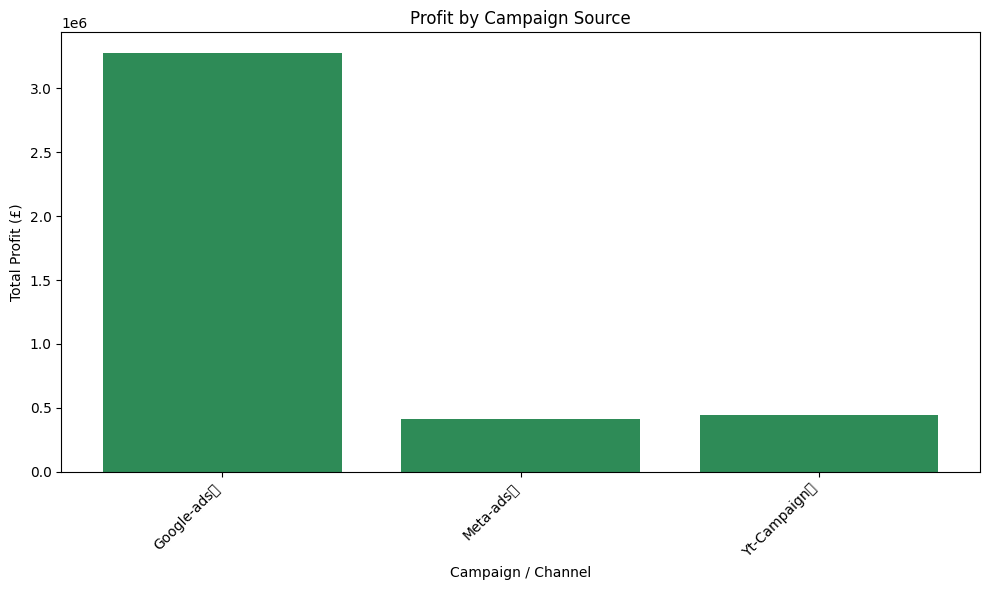

In [ ]:
#visualisation
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(financial_summary["AcquisitionSource"], financial_summary["Total_Profit"], color="seagreen")
plt.title("Profit by Campaign Source")
plt.xlabel("Campaign / Channel")
plt.ylabel("Total Profit (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
#Risk Management (Failed Payments & Fraud)
#Analyze payment failures, frauds, or chargebacks to assess financial risk.
risk_summary = (
    df.groupby(["PaymentMethod", "Fraud"])
      .agg(
          Transactions=("OrderID", "nunique"),
          Revenue_Lost=("Revenue", lambda x: x[df["Fraud"]=="Yes"].sum()),
          Total_Revenue=("Revenue", "sum")
      )
      .reset_index()
)
risk_summary["Fraud_Rate_%"] = (df["Fraud"].value_counts(normalize=True) * 100).get("Yes", 0)
risk_summary

,PaymentMethod,Fraud,Transactions,Revenue_Lost,Total_Revenue,Fraud_Rate_%
0,CREDITCARD,False,9364,0.0,8.408048e+06,0
1,CREDITCARD,True,911,0.0,4.050373e+05,0
2,PAYPAL,False,1868,0.0,8.536983e+05,0
3,PAYPAL,True,100,0.0,5.023608e+04,0


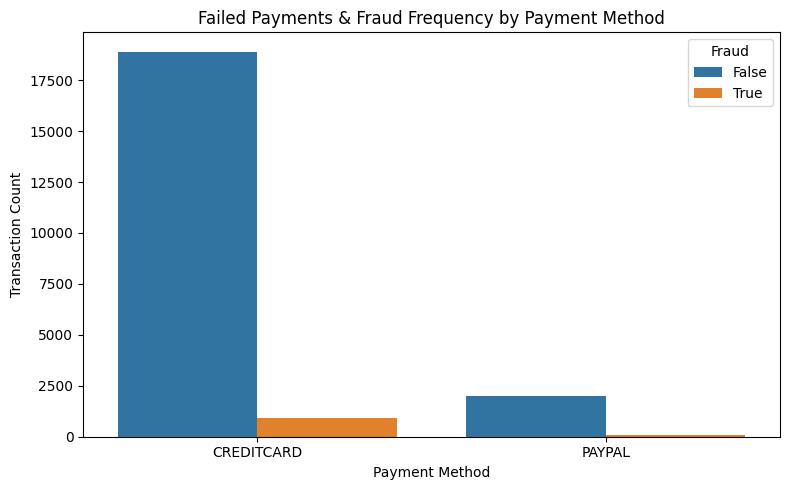

In [ ]:
#visualisation
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="PaymentMethod", hue="Fraud")
plt.title("Failed Payments & Fraud Frequency by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

In [ ]:
#Transaction Volume Analysis
#Analyze transaction volumes over daily, weekly, and monthly periods to identify trends and seasonal patterns.

df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["Week"] = df["OrderDate"].dt.to_period("W").apply(lambda r: r.start_time)
df["Month"] = df["OrderDate"].dt.to_period("M").apply(lambda r: r.start_time)

# Daily volume
daily_volume = df.groupby("OrderDate")["OrderID"].nunique().reset_index()
# Weekly volume
weekly_volume = df.groupby("Week")["OrderID"].nunique().reset_index()
# Monthly volume
monthly_volume = df.groupby("Month")["OrderID"].nunique().reset_index()

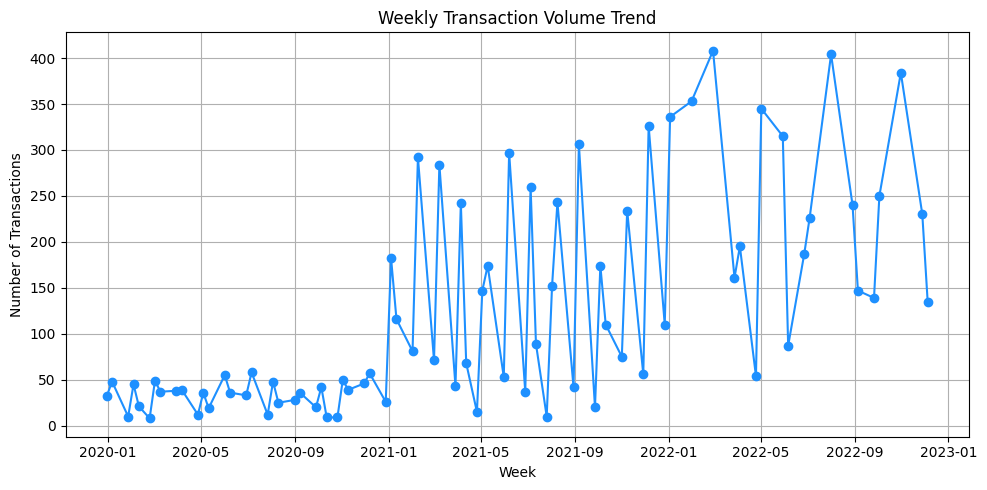

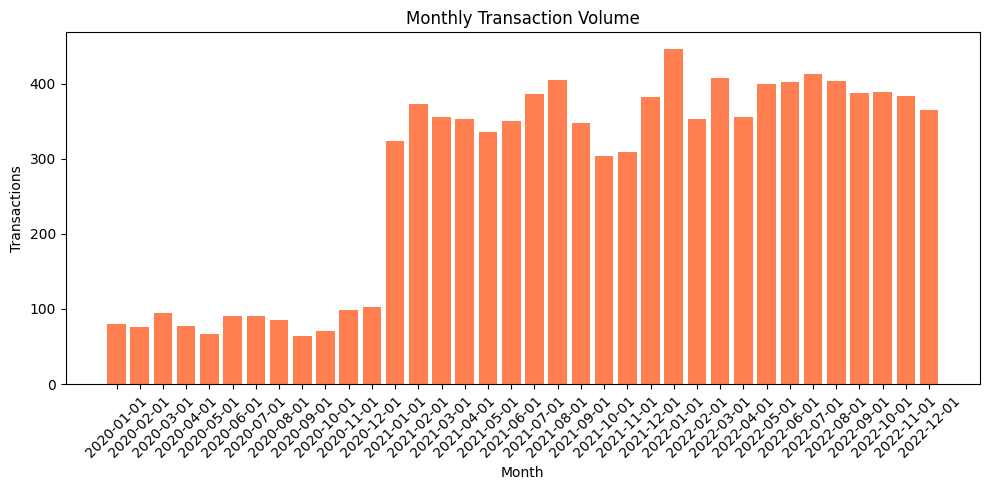

In [ ]:
#visuals
plt.figure(figsize=(10,5))
plt.plot(weekly_volume["Week"], weekly_volume["OrderID"], marker="o", color="dodgerblue")
plt.title("Weekly Transaction Volume Trend")
plt.xlabel("Week")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.bar(monthly_volume["Month"].astype(str), monthly_volume["OrderID"], color="coral")
plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Clean Gender column
df["Gender"] = (
    df["Gender"]
    .astype(str)                  # convert to string
    .str.strip()                  # remove spaces/newlines
    .str.upper()                  # standardize to uppercase
)

# Replace empty, NaN, or weird characters with NaN
df["Gender"] = df["Gender"].replace(
    ["", " ", "NONE", "NAN", "NULL", "0", "U", "X", "P", "N", "Y", "S"],
    np.nan
)

# Optional: If you know blank = female in your data, fill it
# df["Gender"] = df["Gender"].fillna("F")

# Keep only M or F (if you want strict categories)
df.loc[~df["Gender"].isin(["M", "F", "NaN"]), "Gender"] = np.nan


In [ ]:
#Revenue Breakdown by Product/Region
#Understand which services, products, or regions drive the most revenue.
revenue_breakdown = (
    df.groupby(["Region", "Product_Category"])
      .agg(Total_Revenue=("Revenue", "sum"))
      .reset_index()
      .sort_values("Total_Revenue", ascending=False)
)
revenue_breakdown.head(10)

,Region,Product_Category,Total_Revenue
1,Australia,Plants,2.843464e+06
22,Southwest,Plants,1.803906e+06
16,Northwest,Plants,1.100541e+06
25,United Kingdom,Plants,1.095517e+06
11,Germany,Plants,9.773677e+05
8,France,Plants,8.490759e+05
4,Canada,Plants,6.410022e+05
21,Southwest,Plant Care & Seeds,7.396337e+04
0,Australia,Plant Care & Seeds,6.978840e+04
15,Northwest,Plant Care & Seeds,5.638586e+04


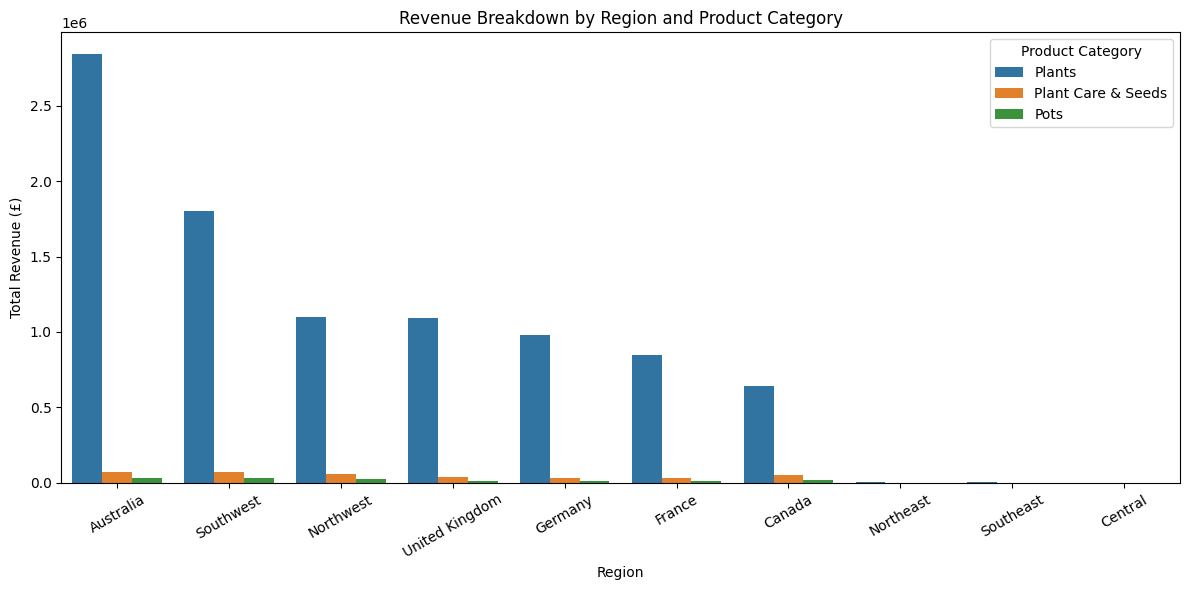

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=revenue_breakdown, x="Region", y="Total_Revenue", hue="Product_Category")
plt.title("Revenue Breakdown by Region and Product Category")
plt.xlabel("Region")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=30)
plt.legend(title="Product Category")
plt.tight_layout()
plt.show()

In [ ]:
#Revenue Breakdown by Product/Region
#Understand customer base distribution (gender, country, region) to inform marketing segmentation.

demographics = df.groupby(["Gender", "Region"]).agg(
    Customers=("CustID", "nunique"),
    Revenue=("Revenue", "sum")
).reset_index()

gender_distribution = (
    df["Gender"].fillna("Unspecified")
    .value_counts(normalize=True) * 100
)
#gender_distribution = df["Gender"].value_counts(normalize=True) * 100
gender_distribution

,proportion
Gender,
M,87.228298
Unspecified,12.771702


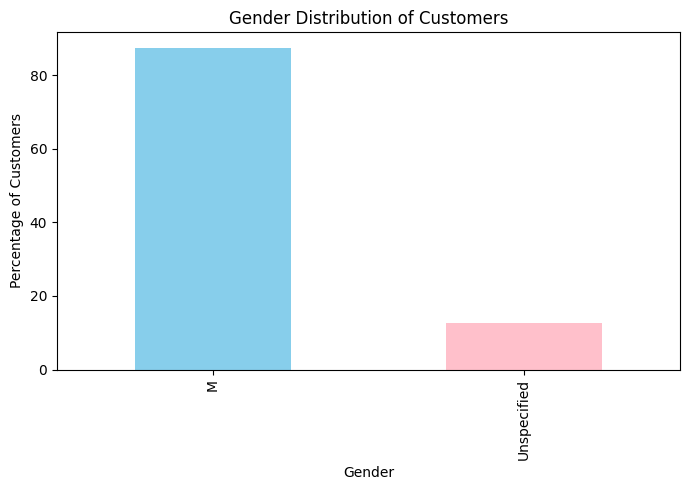

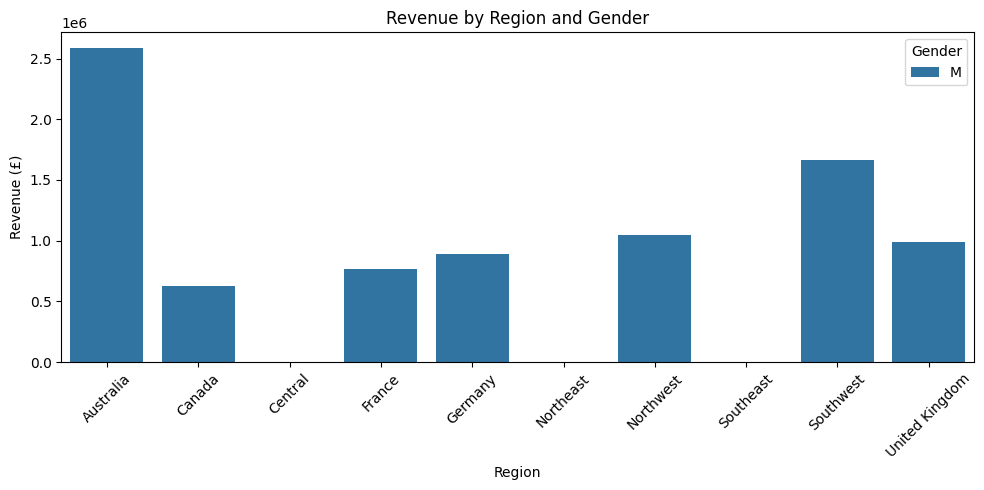

In [ ]:
plt.figure(figsize=(7,5))
gender_distribution.plot(kind="bar", color=["skyblue","pink"])
plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Percentage of Customers")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=demographics, x="Region", y="Revenue", hue="Gender")
plt.title("Revenue by Region and Gender")
plt.xlabel("Region")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["Gender"].value_counts(dropna=False)

,count
Gender,
M,19383
NaN,2838
